In [1]:
%load_ext autoreload
%autoreload 2

Environment created. Action dimension is: 8
odict_keys(['robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'frontview_image', 'birdview_image', 'agentview_image', 'cube_pos', 'cube_quat', 'gripper_to_cube_pos', 'robot0_proprio-state', 'object-state'])
(7,)
odict_keys(['robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'frontview_image', 'birdview_image', 'agentview_image', 'cube_pos', 'cube_quat', 'gripper_to_cube_pos', 'robot0_proprio-state', 'object-state'])
(7,)
odict_keys(['robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'frontview_image', 'birdview_image', 'agentview_image', 'cube_pos', 'cube_quat', 'gripper_to_cube_pos', 'robot0_proprio-state', 'object-state'])
(7,)
odict_keys(['robo

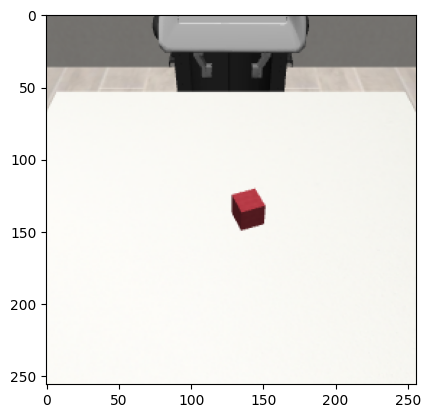

In [11]:
import robosuite as suite
import numpy as np
from robosuite.environments.manipulation.lift import Lift   
import matplotlib.pyplot as plt
# 1. Create environment
env = suite.make(
    env_name="Lift",
    robots="Panda",
    has_renderer=False,  # 可以设为False，因为我们用相机观测
    has_offscreen_renderer=True,  # 启用离屏渲染
    use_camera_obs=True,  # 启用相机观测
    camera_names=["frontview", "birdview", "agentview"],  # 指定相机名称
    camera_heights=256,  # 图像高度
    camera_widths=256,   # 图像宽度
    control_freq=20,
)
# 2. Reset environment and run loop
obs = env.reset()

# --- THIS IS THE CORRECTED LINE ---
# env.action_spec is a tuple (min_action_bounds, max_action_bounds)
# We get the shape from the first element of that tuple.
action_dim = env.action_spec[0].shape[0]
# ------------------------------------

print(f"Environment created. Action dimension is: {action_dim}")

# Run for 1000 steps
for i in range(5):
    # Generate a random action within the valid bounds [-1, 1]
    action = np.random.uniform(low=-1.0, high=1.0, size=action_dim)

    # Execute the action in the environment
    obs, reward, done, info = env.step(action)
    print(obs.keys())
    velocity = obs["robot0_joint_vel"]
    print(velocity.shape)
    # Render the scene
    # env.render()

    # If the episode is over, reset the environment
    if done:
        print(f"Episode finished after {i + 1} timesteps.")
        obs = env.reset()

img = np.ascontiguousarray(obs["agentview_image"][::-1, ::-1])
plt.imshow(img)
# 3. Close the environment
env.close()

print("Demo finished.")